<a href="https://colab.research.google.com/github/loreslei/Sistemas-Distribuidos-Analitico/blob/main/metricas_e_estocastico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primeira Parte: Métricas

In [52]:
import math
import random
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
# Função do cálculo da disponibilidade
def calcular_disponibilidade(n, k, p):
    disp = 0
    for i in range(k, n + 1):
        disp += math.comb(n, i) * (p ** i) * ((1 - p) ** (n - i))
    return disp


In [54]:
# Tabelas com pandas
print("\n" + "="*50)
print("TABELA 1: Variação da Confiabilidade (p) para n=10")
print("="*50)
p_amostra = [0.50, 0.70, 0.85, 0.90, 0.95, 0.99]
k_amostra = [1, 3, 5, 8, 10]
dados_t1 = []

for p in p_amostra:
    linha = {'p (Probabilidade)': p}
    for k in k_amostra:
        linha[f'k={k}'] = calcular_disponibilidade(10, k, p)
    dados_t1.append(linha)

df1 = pd.DataFrame(dados_t1)
display(df1.style.hide(axis="index").format("{:.5f}"))

print("\n" + "="*50)
print("TABELA 2: Escalonamento do Cluster (n) com p=0.85")
print("="*50)
dados_t2 = []

for n in range(1, 16, 2):
    dados_t2.append({
        'n (Tamanho Cluster)': n,
        'k=1 (Consulta)': calcular_disponibilidade(n, 1, 0.85),
        'k=n/2 (Quórum)': calcular_disponibilidade(n, math.ceil(n / 2), 0.85),
        'k=n (Estrita)': calcular_disponibilidade(n, n, 0.85)
    })

df2 = pd.DataFrame(dados_t2)
display(df2.style.hide(axis="index").format("{:.5f}"))

print("\n" + "="*50)
print("TABELA 3: Tolerância à Restrição (k) para n=10")
print("="*50)
dados_t3 = []
p_testes = [0.5, 0.7, 0.9, 0.99]

for k in range(1, 11):
    linha = {'k (Mín. Exigido)': k}
    for p in p_testes:
        linha[f'p={p}'] = calcular_disponibilidade(10, k, p)
    dados_t3.append(linha)

df3 = pd.DataFrame(dados_t3)
display(df3.style.hide(axis="index").format("{:.5f}"))

print("\n" + "="*50)
print("TABELA 4: Descoberta de N para Disponibilidade Alvo (f)")
print("="*50)
p_alvo = 0.5
k_alvo = 1
disponibilidades_alvo = [0.90, 0.99, 0.999, 0.9999, 0.99999, 0.999999]
nomes_disp = ['90%', '99%', '99.9%', '99.99%', '99.999%', '99.9999%']
dados_t4 = []

for f, nome in zip(disponibilidades_alvo, nomes_disp):
    # Fórmula: N >= log(1-f) / log(1-p)
    n_min = math.ceil(math.log(1 - f) / math.log(1 - p_alvo))
    dados_t4.append({
        'Disponibilidade (f)': nome,
        'f (decimal)': f,
        'N mínimo necessário': n_min
    })

df4 = pd.DataFrame(dados_t4)
display(df4.style.hide(axis="index"))


TABELA 1: Variação da Confiabilidade (p) para n=10


p (Probabilidade),k=1,k=3,k=5,k=8,k=10
0.50000,0.99902,0.94531,0.62305,0.05469,0.00098
0.70000,0.99999,0.99841,0.95265,0.38278,0.02825
0.85000,1.00000,0.99999,0.99862,0.82020,0.19687
0.90000,1.00000,1.00000,0.99985,0.92981,0.34868
0.95000,1.00000,1.00000,1.00000,0.98850,0.59874
0.99000,1.00000,1.00000,1.00000,0.99989,0.90438



TABELA 2: Escalonamento do Cluster (n) com p=0.85


n (Tamanho Cluster),k=1 (Consulta),k=n/2 (Quórum),k=n (Estrita)
1.00000,0.85000,0.85000,0.85000
3.00000,0.99662,0.93925,0.61412
5.00000,0.99992,0.97339,0.44371
7.00000,1.00000,0.98790,0.32058
9.00000,1.00000,0.99437,0.23162
11.00000,1.00000,0.99734,0.16734
13.00000,1.00000,0.99873,0.12091
15.00000,1.00000,0.99939,0.08735



TABELA 3: Tolerância à Restrição (k) para n=10


k (Mín. Exigido),p=0.5,p=0.7,p=0.9,p=0.99
1.00000,0.99902,0.99999,1.00000,1.00000
2.00000,0.98926,0.99986,1.00000,1.00000
3.00000,0.94531,0.99841,1.00000,1.00000
4.00000,0.82812,0.98941,0.99999,1.00000
5.00000,0.62305,0.95265,0.99985,1.00000
6.00000,0.37695,0.84973,0.99837,1.00000
7.00000,0.17188,0.64961,0.98720,1.00000
8.00000,0.05469,0.38278,0.92981,0.99989
9.00000,0.01074,0.14931,0.73610,0.99573
10.00000,0.00098,0.02825,0.34868,0.90438



TABELA 4: Descoberta de N para Disponibilidade Alvo (f)


Disponibilidade (f),f (decimal),N mínimo necessário
90%,0.900000,4
99%,0.990000,7
99.9%,0.999000,10
99.99%,0.999900,14
99.999%,0.999990,17
99.9999%,0.999999,20


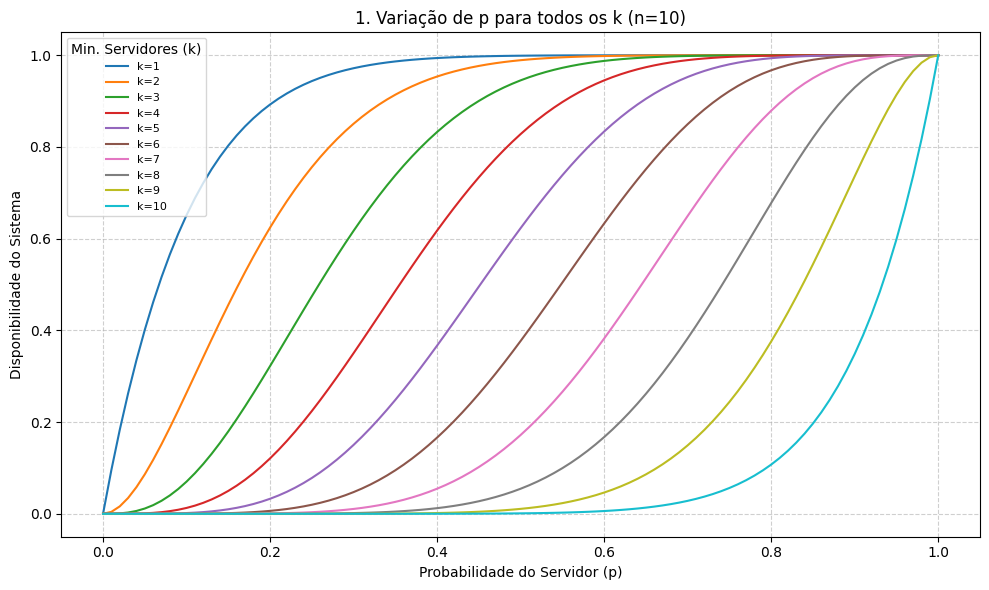

In [55]:
# --- Grafico 1: Fixando 'n', variando 'p' para TODOS os 'k' ---
plt.figure(figsize=(10, 6))
n_fixo_1 = 10
p_vals = [x / 100.0 for x in range(0, 101)]

for k in range(1, n_fixo_1 + 1):
    disp_vals = [calcular_disponibilidade(n_fixo_1, k, p) for p in p_vals]
    plt.plot(p_vals, disp_vals, label=f'k={k}')

plt.title(f'1. Variação de p para todos os k (n={n_fixo_1})')
plt.xlabel('Probabilidade do Servidor (p)')
plt.ylabel('Disponibilidade do Sistema')
plt.legend(title="Min. Servidores (k)", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

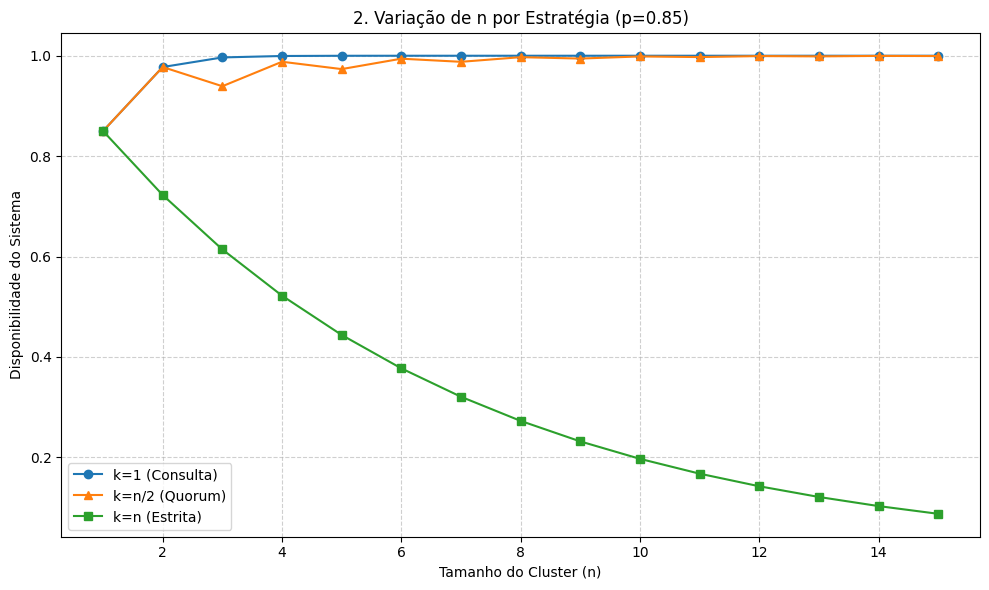

In [56]:
# --- Grafico 2: Fixando 'p', variando 'n' para as 3 estrategias ---
plt.figure(figsize=(10,6))
p_fixo_2 = 0.85
n_vals_g2 = list(range(1, 16))

disp_k1 = [calcular_disponibilidade(n, 1, p_fixo_2) for n in n_vals_g2]
disp_quorum = [calcular_disponibilidade(n, math.ceil(n / 2), p_fixo_2) for n in n_vals_g2]
disp_kn = [calcular_disponibilidade(n, n, p_fixo_2) for n in n_vals_g2]

plt.plot(n_vals_g2, disp_k1, marker='o', label='k=1 (Consulta)')
plt.plot(n_vals_g2, disp_quorum, marker='^', label='k=n/2 (Quorum)')
plt.plot(n_vals_g2, disp_kn, marker='s', label='k=n (Estrita)')

plt.title(f'2. Variação de n por Estratégia (p={p_fixo_2})')
plt.xlabel('Tamanho do Cluster (n)')
plt.ylabel('Disponibilidade do Sistema')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

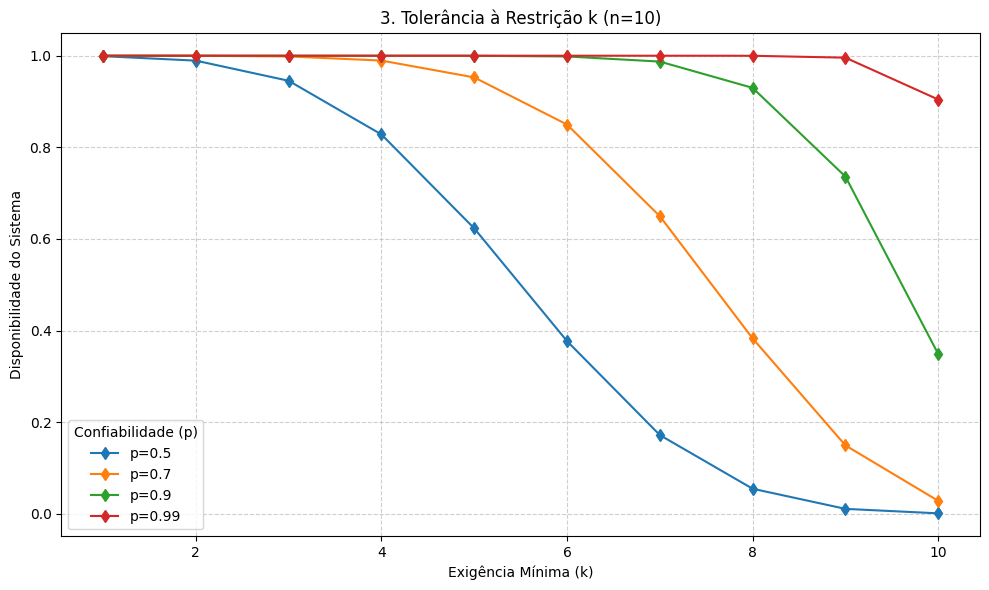

In [57]:
# --- Grafico 3: Fixando 'n', variando 'k' ---
plt.figure(figsize=(10, 6))
n_fixo_3 = 10
k_vals = list(range(1, n_fixo_3 + 1))

for p in p_testes:
    disp_vals = [calcular_disponibilidade(n_fixo_3, k, p) for k in k_vals]
    plt.plot(k_vals, disp_vals, marker='d', label=f'p={p}')

plt.title(f'3. Tolerância à Restrição k (n={n_fixo_3})')
plt.xlabel('Exigência Mínima (k)')
plt.ylabel('Disponibilidade do Sistema')
plt.legend(title="Confiabilidade (p)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

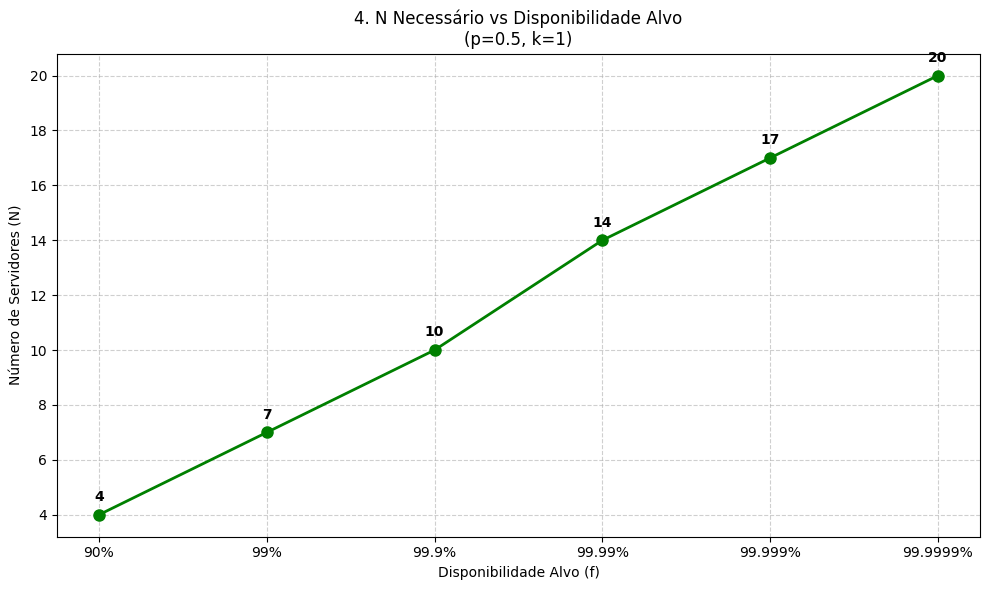

In [58]:
# --- Grafico 4: N Necessário vs Disponibilidade (f) ---
plt.figure(figsize=(10, 6))
n_vals_g4 = [d['N mínimo necessário'] for d in dados_t4]
plt.plot(nomes_disp, n_vals_g4, marker='o', color='green', linewidth=2, markersize=8)
for i, n_val in enumerate(n_vals_g4):
    plt.text(i, n_val + 0.5, str(n_val), ha='center', fontsize=10, fontweight='bold')

plt.title(f'4. N Necessário vs Disponibilidade Alvo\n(p={p_alvo}, k={k_alvo})')
plt.xlabel('Disponibilidade Alvo (f)')
plt.ylabel('Número de Servidores (N)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Parte 2: Estocástico

In [59]:
# Funções e valores
def probabilidade_analitica(n, k, p):
    disp = 0
    for i in range(k, n + 1):
        disp += math.comb(n, i) * (p ** i) * ((1 - p) ** (n - i))
    return disp

def simulador_estocastico(n, k, p, num_rodadas):
    sucessos = 0
    for _ in range(num_rodadas):
        online = sum(1 for _ in range(n) if random.random() <= p)
        if online >= k:
            sucessos += 1
    return sucessos / num_rodadas



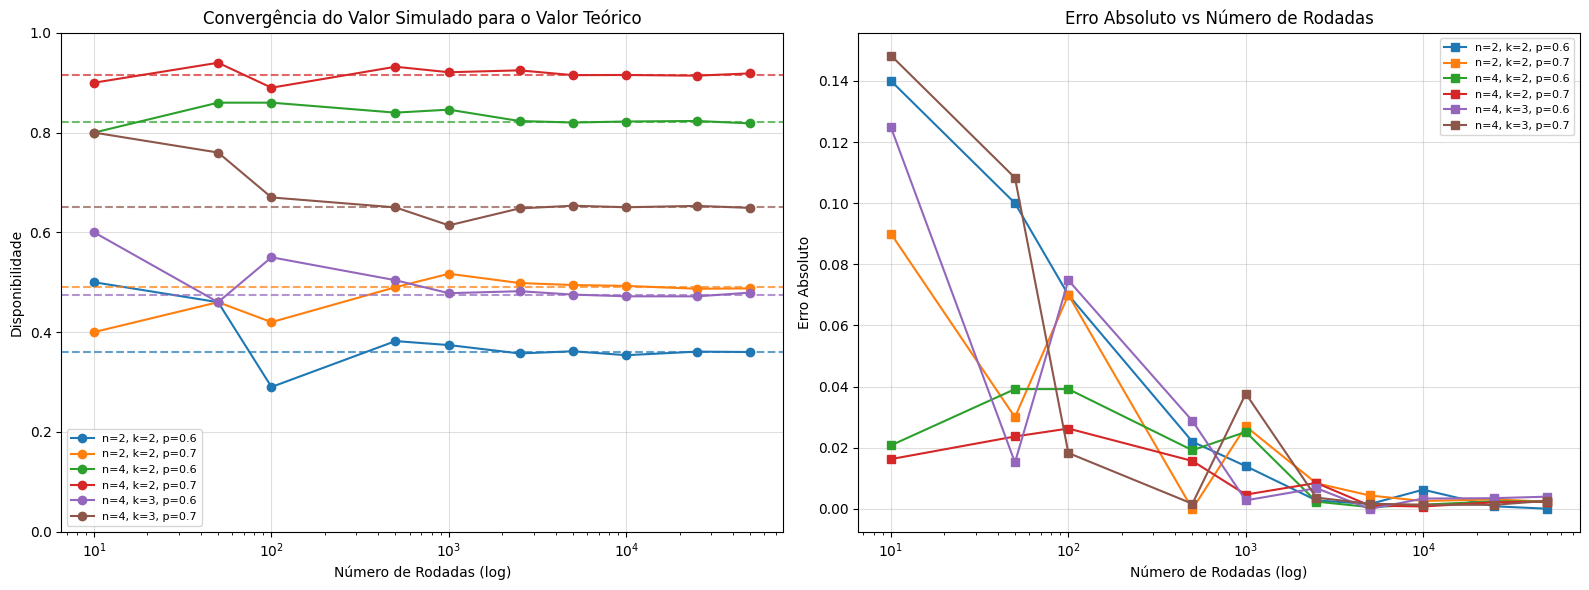

In [60]:
# Plots e testes
n_vals = [2, 4]
k_vals = [2, 3]
p_vals = [0.6, 0.7]

rodadas_lista = [10, 50, 100, 500, 1000, 2500, 5000, 10000, 25000, 50000]
dados_tabela = []
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for n_teste in n_vals:
    for k_teste in k_vals:

        if k_teste > n_teste:
            continue

        for p_teste in p_vals:

            teorico = probabilidade_analitica(n_teste, k_teste, p_teste)

            resultados_simulados = []
            erros = []

            for N in rodadas_lista:

                simulado = simulador_estocastico(n_teste, k_teste, p_teste, N)
                erro = abs(teorico - simulado)

                resultados_simulados.append(simulado)
                erros.append(erro)

                dados_tabela.append({
                    "n": n_teste,
                    "k": k_teste,
                    "p": p_teste,
                    "Rodadas": N,
                    "Valor Teórico": teorico,
                    "Valor Simulado": simulado,
                    "Erro Absoluto": erro
                })

            label = f"n={n_teste}, k={k_teste}, p={p_teste}"

            linha = ax1.plot(rodadas_lista, resultados_simulados, marker='o', label=label)

            cor = linha[0].get_color()

            ax1.axhline(
                y=teorico,
                linestyle="--",
                linewidth=1.5,
                color=cor,
                alpha=0.7
            )

            ax2.plot(rodadas_lista, erros, marker='s', color=cor, label=label)

ax1.set_xscale('log')
ax1.set_ylim(0,1)
ax1.set_title("Convergência do Valor Simulado para o Valor Teórico")
ax1.set_xlabel("Número de Rodadas (log)")
ax1.set_ylabel("Disponibilidade")
ax1.grid(True, alpha=0.4)
ax1.legend(fontsize=8)

ax2.set_xscale('log')
ax2.set_title("Erro Absoluto vs Número de Rodadas")
ax2.set_xlabel("Número de Rodadas (log)")
ax2.set_ylabel("Erro Absoluto")
ax2.grid(True, alpha=0.4)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [61]:
# ----- Tabela -----

df_resultados = pd.DataFrame(dados_tabela)

print("\n=== Teoria x Simulação ===")

display(
    df_resultados.style
    .hide(axis="index")
    .format({
        "Valor Teórico": "{:.6f}",
        "Valor Simulado": "{:.6f}",
        "Erro Absoluto": "{:.6f}"
    })
)


=== Teoria x Simulação ===


n,k,p,Rodadas,Valor Teórico,Valor Simulado,Erro Absoluto
2,2,0.600000,10,0.360000,0.500000,0.140000
2,2,0.600000,50,0.360000,0.460000,0.100000
2,2,0.600000,100,0.360000,0.290000,0.070000
2,2,0.600000,500,0.360000,0.382000,0.022000
2,2,0.600000,1000,0.360000,0.374000,0.014000
2,2,0.600000,2500,0.360000,0.357200,0.002800
2,2,0.600000,5000,0.360000,0.361600,0.001600
2,2,0.600000,10000,0.360000,0.353700,0.006300
2,2,0.600000,25000,0.360000,0.360880,0.000880
2,2,0.600000,50000,0.360000,0.360080,0.000080
